# Sistemas de ecuaciones

Consideremos el sistema:

$$x + y =3$$
$$3x - 4y = 2$$

Desde el punto de vista geomético la solución a este sistema es el punto de corte entre ambas rectas

<center>

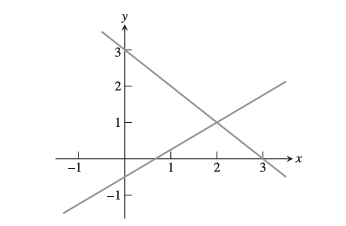

<center>

Para resolver este sistema es posible hacer uso del algoritmo de **eliminación gaussiana**. Se busca llevar la parte de la matriz que contiene los coeficientes del sistema de ecuaciones lineales a una forma triangular superior. Luego solo debe sustituirse hacia atrás

La etapa de eliminación consiste en conseguir los ceros de la parte inferior de la matriz, esto toma

```
for j in range(n-1):
        poner ceros en cada columna j
````

Ahora, hacer esta operación para cada columna implica, por ejemplo para la primera columna, poner ceros en $a_{21},...a_{n1}$

```
for j in range(n-1):
        for i in range(j+1, n):
                eliminar entrada a(i,j)
````

Las entradas princiales de cada columna que no son cero se denominan pivotes.

Eliminar cada entrada $a_{in}$ requiere 2n + 1 operaciones (una división, una n multiplicaciones y n sumas)

Hacerlo para cada columna requiere hacerlo n - 1 veces.

<center>

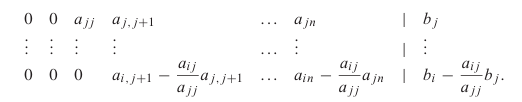

<center>




Considerando podemos ahorrarnos las operaciones por cero, necesitamos para cada elemento $a_{ij}$, una división, n - j + 1 multiplicaciones y n - j + 1 sumas/restas.

In [35]:
import numpy as np

# Por el momento no se consideran intercambios de filas
# Matrices de n ecuaciones y n incognitas

matriz = np.array([[2,2,3],[2,4,3],[1,2,3]], dtype = float)
b = np.array([[2],[1],[4]], dtype=float)

n = matriz.shape[1]-1

for j in range(n):
    if abs(matriz[j,j]) < 1e-15:
        print('Error pivote cero')
        break
    
    for i in range(j+1, n + 1):
        print(i,j+1)
        
        mult = matriz[i,j]/matriz[j,j]
        
        # Aunque esta parte parezca un error
        # Hacerlo de esta manera es eficiente puesto que no necesitamos
        # Hacer ninguna operación sobre el elemento a_ij posteriormente
        
        matriz[i,j+1:] = matriz[i,j+1:] - mult*matriz[j,j+1:]

        
        b[i] = b[i] - mult*b[j]

print(matriz)
print(b)



1 1
2 1
2 2
[[2.  2.  3. ]
 [2.  2.  0. ]
 [1.  1.  1.5]]
[[ 2. ]
 [-1. ]
 [ 3.5]]


In [36]:
sol = np.zeros((n+1,1))

for i in range(n,-1,-1):
    sol[i] = b[i]

    for j in range(n,i,-1):

        sol[i] -= matriz[i,j]*sol[j]

    sol[i] = sol[i]/matriz[i,i]



print(sol)

[[-2.        ]
 [-0.5       ]
 [ 2.33333333]]


El número total de operaciones necesarias para la eliminación es de 

$$\sum_{j=1}^{n-1} \sum_{i=1}^{j} 2(j+1)+1 = \frac{2}{3}n^3 + \frac{1}{2}n^2 - \frac{7}{6}n \approx \frac{2}{3}n^3$$

Al terminar obtenemos el siguiente sistema:

<center>

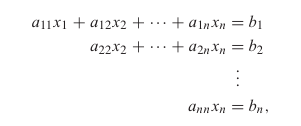

<center>

Para obtener las soluciones con sustitución hacia atrás:

$$x_n = \frac{b_n}{a_{nn}}$$
Y sustituyendo hasta:
$$x_1 = \frac{b_1 - a_{1n}x_n - ... - a_{12}x_2}{a_{11}}$$

La cantidad de operaciones son:

$$1 + 3 + 5 + ... + (2n - 1) = \sum_{i = 1}^n 2i - 1 = n^2$$

En conclusión podríamos decir que la eliminación gaussiana toma aproximadamente $\frac{2}{3}n^3$ operaciones o en notación de Big O, $O(n^3)$

# La factorización LU

Un sistema $Ax = b$ puede escribirse como:

$$
\begin{bmatrix} 1 & 1 \\ 3 & -4 \\ \end{bmatrix} \begin{bmatrix} x1 \\ x2\end{bmatrix} = \begin{bmatrix} 3 \\ 2 \end{bmatrix}
$$

La matriz de coefientes es $A$ y el vector del lado derecho es $b$.
Se desea encontrar un $x$ tal que el vector $Ax$ sea el vector $b$.
O en otras palabras, que $Ax$ y $b$ coincidan en todas su componentes.

La factorización $LU$ consiste en escribir a la matriz de coeficientes A, como un producto de una matriz triangular inferior $L$ y una matriz triangular superior $U$. Fragmenta un objeto complicado en varias partes.

Un ejemplo sería:

$$\begin{bmatrix} 1 & 1 \\ 3 & -4 \end{bmatrix} = \begin{bmatrix} 1 & 1 \\ 0 & -7 \end{bmatrix} = U$$

Lo que se hizo fue lleva a la matrix a su forma escalonada, esta será la parte $U$ de la factorización.
 Ahora $L$ será una matriz con unos en la diagonal y que guarda los coeficientes correspondientes a las multiplicaciones hechas al pivote para generar ceros en la matriz $A$. En este caso, para llevar a $A$ a la forma escalonada lo que se hizo fue multiplicar 3 a la primera fila y luego restarla a la segunda. Por lo tanto en la primera entrada de la segunda fila colocamos 3.

 $$\begin{bmatrix} 1 & 0 \\ 3 & 1 \end{bmatrix}$$

Si se hacen más operaciones el procedimiento es análogo.

Y llegamos a:

$$\begin{bmatrix} 1 & 0 \\ 3 & 1 \end{bmatrix} \begin{bmatrix} 1 & 1 \\ 0 & -7 \end{bmatrix} = \begin{bmatrix} 1 & 1 \\ 3 & -4 \end{bmatrix} = A$$



Esto funciona por 3 hechos fundamentales:

Sea $L_{ij}(-c)$ la matriz triangular inferior, cuyas únicas entradas diferentes de cero son unos en la diagonal principal y -c en la posición (i,j). Entonces $A \rightarrow L_{ij}(-c)A$ representa la operación por reglón restar c veces el renglón j del renglón i.

<center>

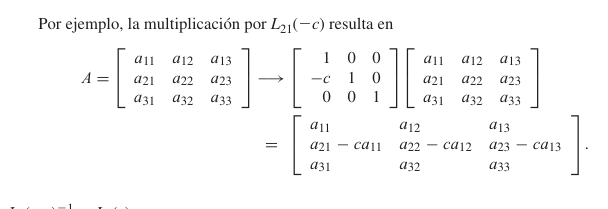

<center>

Además $L_{ij}(-c)^{-1} = L_{ij}(c)$

Entonces esto el ejemplo dado de la factorización LU puede entenderse como:
$$L_{21}(-3)A = \begin{bmatrix} 1 & 1 \\ 0 & -7 \end{bmatrix} = U$$

Luego, entonces como $L_{ij}(-c)^-1 = L_{ij}(c)$:

$$L_{21}(-3)A = U$$
$$L_{21}(-c)^{-1}L_{21}(-3)A = L_{21}(-c)^{-1}U$$
$$IA = L_{21}(-c)^-1U$$
$$A = L_{21}(-c)^-1U = LU$$



Y luego para generalizar todas las operaciones de resta se usa el siguiente hecho:

<center>

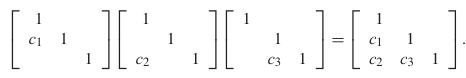

<center>

Ahora, como se conocen $L$ y $U$, problema $Ax = b$ puede expresarse como $LUx = b$. Definiendo el vector auxiliar $c = Ux$. Entonces la sustitución atrás consiste en:

1. Resolver $Lc = b$ para $c$ 
2. Resolver $Ux = c$ para $x$

$$\begin{bmatrix} 1 & 1 \\ 3 & -4 \end{bmatrix} = LU = \begin{bmatrix} 1 & 0 \\ 3 & 1 \end{bmatrix} \begin{bmatrix} 1 & 1 \\ 0 & -7 \end{bmatrix}$$

Resolver $Lc = b$ para por ejemplo $b = [3,2]$ se resumen en:

$$\begin{bmatrix} 1 & 0 \\ 3 & 1 \end{bmatrix} \begin{bmatrix} c_{11} \\ c_{21} \end{bmatrix} = \begin{bmatrix} 3 \\ 2 \end{bmatrix}$$

Y resolver $Ux = c$:

$$\begin{bmatrix} 1 & 1 \\ 0 & -7 \end{bmatrix} \begin{bmatrix} x_{11} \\ x_{21} \end{bmatrix} = \begin{bmatrix} c_{11} \\ c_{21} \end{bmatrix}$$

$$c_{11} = 3$$
$$3c_{11} + c_{21} = 2$$
$$c_{21} = 2 - 3(3) = -7$$

$$\begin{bmatrix} 1 & 1 \\ 0 & -7 \end{bmatrix} \begin{bmatrix} x_{11} \\ x_{21} \end{bmatrix} = \begin{bmatrix} 3 \\ -7 \end{bmatrix}$$

$$ x_{11} + x_{21} = 3$$
$$ -7x_{21} = -7$$
$$ x_{21} = 1$$
$$ x_{11} = 3 - 1 = 2$$

# Complejidad de la factorización LU

Imagine que es necesario reslver más de un problema $Ax = b$ con la misma $A$ pero diferente $b$

$$Ax = b1$$
$$Ax = b_k$$

La eliminación gaussiana clásica requeriría $2kn^3/3$ operaciones. En el enfoque $LU$, las $b_i$ participan hasta realizada la factorización $LU$ (procesos de eliminación). El cálculo se simplifica al solo tener que realziar una sola eliminación y dos sustituciones hacia atrás para cada $b_i$ ($Lc = b_i$ y $Ux = c$). Entonces el total de operaciones se reduce a $\frac{2n^3}{3} + 2kn^2 $. Lastimosamente no todas las matrices permiten factorización LU.

# Fuentes de Error

La norma infinito o norma máximo de un vector $x = (x_1,...x _n)$ es $\lvert \lvert x \rvert \rvert_{\inf} = max \lvert x _i \rvert, i = 1,...,n$. El máximo de los valores absolutos de las componentes de x.

El error hacia atrás nuevamente son las diferencias en la entrada de los datos y el error hacia adelante las diferencias en la salida del algoritmo.

Sea $x_a$ una solución aproximada del sistema lineal $Ax = b$. El residuo es el vector $r = b - Ax_a$. El error hacia atrás es la norma del residuo  $\lvert \lvert b - Ax_a \rvert \rvert_{\inf}$ y el error hacia adelante es $\lvert \lvert x - x_a \rvert \rvert_{\inf}$

Los errores hacia adelante y hacia atrás pueden ser de diferentes magnitudes, por ejemplo, en un sistema que represente la intersección de dos rectas, si las rectas son casi paralelas, el error hacia atrás puede ser pequeño pero el error hacia adelante grande.

El error relativio hacia atrás es:

$$\frac{\lvert \lvert r \rvert \rvert_{\inf}}{\lvert \lvert b \rvert \rvert_{\inf}}$$

El error relativo hacia adelante:

$$\frac{\lvert \lvert x - x_a \rvert \rvert_{\inf}}{\lvert \lvert x \rvert \rvert_{\inf}}$$

El factor de magnificancia del error es dividir ambos errores relativos

Recordemos que es el error hacia adelante sobre el error hacia atrás

$$\frac{\frac{\lvert \lvert r \rvert \rvert_{\inf}}{\lvert \lvert b \rvert \rvert_{\inf}}}{\frac{\lvert \lvert x - x_a \rvert \rvert_{\inf}}{\lvert \lvert x \rvert \rvert_{\inf}}}$$


El número de una condición de una matriz cuadrada es:

$$cond(A) = \lvert\lvert A\rvert\rvert \cdot \lvert\lvert A^{-1}\rvert\rvert$$

La norma de A se define como el máximo valor absoluto de la suma por renglones, es decir sumar todos los valores absolutos de cada renglón y tomar el máximo.

# Dominancia

Este error sucede más que todo por el redondeo, es más fácil de controlar, solamente se debe procurar que los multiplicadores sean lo más pequeños posibles al momento de realizar la eliminación.

# Pivoteo parcial

La eliminación gaussiana presenta dos problemas, encontrar un pivote cero y la dominancia. La solución a esto es el pivote parcial.

El primer paso en la eliminación gaussiana es usar el elemento $a_{11}$ de la diagonal como pivote para eliminar la primera columna. El pivoteo parcial consiste en comparar los números antes de la ejecución de cada etapa de eliminación. Se busca la entrada más grande la primera columna y su renglón se intercambia con el renglón pivote, en este caso el superior.

Se busca el p-ésimo renglón donde 

$$\lvert a_{pi} \rvert \ge \lvert a_{i1} \rvert$$

E intercambiar los renglones.

Como se puede observar al ser siempre el pivote mayor que los demás elementos de la columna, el multiplicador siempre es un número menor que uno.



In [5]:
import numpy as np

def eliminacion_gaussiana_con_pivoteo(array, vector):
    coeficientes = array.copy()
    b = vector.copy()

    for j in range(coeficientes.shape[1]):

        # Obtenemos el indice del pivote
        pivote = np.argmax(np.abs(coeficientes[j:,j])) + j 
        if np.abs(coeficientes[pivote,j]) <= 1e-15:
            print("Sin solución única")
            break

        coeficientes[[j, pivote]] = coeficientes[[pivote, j]]
       
        b[[j, pivote]] = b[[pivote,j]]
      
        # Las restas solo se hacen a la filas inferiores al pivote
        for i in range(j+1, coeficientes.shape[0]):

            # Ahorramos el calculo de la primera columna, dado que darán cero
            mult = coeficientes[i,j]/coeficientes[j,j]
            coeficientes[i, j + 1:] -= mult*coeficientes[j,j+1:]
            b[i] -= mult*b[j]
            
           

    return coeficientes, b

array = np.array([[1, -1, 3], [-1, 0, -2], [2, 2, 4]], dtype=float)
vector = np.array([[-3], [1], [0]], dtype=float)

coeficientes, b = eliminacion_gaussiana_con_pivoteo(array, vector)


# Si tuvieramos que resolver
# Más de un sistema de ecuaciones donde solo cambie b
# Entonces coeficientes sería nuestra U
# L se consigue guardando en un array dentro del método anterior
# Los multiplos en la posiciones respectivas y diagonal 1

print(coeficientes)
print(b)


def sustitucion_atras(array, vector):
    coeficientes = array.copy()
    soluciones = vector.copy()
    n = coeficientes.shape[0]-1

    for i in range(n, -1, -1):
        for j in range(n, i, -1):

            soluciones[i] -= coeficientes[i,j]*soluciones[j]

        soluciones[i] = soluciones[i]/coeficientes[i,i]

    return soluciones

print(sustitucion_atras(coeficientes,b))




    

[[ 2.   2.   4. ]
 [ 1.  -2.   1. ]
 [-1.   1.   0.5]]
[[ 0. ]
 [-3. ]
 [-0.5]]
[[ 1.]
 [ 1.]
 [-1.]]


# Matrices de permutación

Una matriz de permutación es una matriz cuadrada que consta sólo de ceros, a excepción de un 1 en cada renglón y columna. También puede pensarse que una matriz de permutación se consigue intercambiando columnas o filas de la matriz identidad $nxn$.

Por ejemplo:

$$\begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} \,\,, \,\, \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}$$

**Teorema fundamental de las matrices de permutación**

Sea P una matriz de pemrutación de $n x n$ formada por un conjunto particular de intercambios de filas aplicada a la matriz identidad. Entonces, para cualquier matriz A de $ n x n $, PA es la matriz obtenida al aplicar exactamente la misma serie de intercambios de fila a A.

En otras palabras:

$$\begin{bmatrix} 1 & 0 & 0 \\ 0 & 0 & 1 \\ 0 & 1 & 0 \end{bmatrix} \begin{bmatrix}a & b & c\\ d & e & f \\ g & h & i \end{bmatrix} = \begin{bmatrix}a & b & c \\ g & h & i \\ d & e & f \end{bmatrix}$$

# Factorizacion PA = LU

Para aplicarla lo único que debe hacerse es guardar la información del intercambio de renglones. Además debe trabajarse primero solamente con la matriz de coeficientes y luego resolverse los sistemas correspondientes con sustitución hacia atrás. Al final el sistema se resume:

$$PA_x = Pb$$
$$LUx = Pb$$

$$Lc = Pb$$
$$Ux = c$$



In [ ]:
import numpy as np

def factorizacion_LU(array):

    if U.shape[0] != U.shape[1]:
        raise ValueError('La matriz no es cuadrada')
    
    U = array.copy()
    n = U.shape[0]
    P = np.eye(n)
    L = np.eye(n)
    
    for j in range(n):

        pivote = np.argmax(np.abs(U[j:,j])) + j

        if np.abs(U[pivote,j]) < 1e-15:
            raise ValueError('Sistema sin solución única')

        U[[j, pivote]] = U[[pivote, j]]
        P[[j, pivote]] = P[[pivote, j]]
        if j > 0:
            L[[j, pivote],:j] = L[[pivote, j],:j]

        for i in range(j+1, n):
            mult = U[i,j]/U[j,j]
            U[i,j+1:] -= mult*U[j,j+1:]
            U[i,j] = 0
            L[i,j] = mult

    
    return L, U, P

A = np.array([[2, 1, 5], [4, 4, -4], [1, 3, 1]], dtype=float)

L, U,  P = factorizacion_LU(A)

# PAx = Pb
# LUx = Pb
# Lc = b
# Ux = c

b = np.array([5,0,6])

def resolver_sistema(L, U, P, b):


    if b.shape[0] != U.shape[0]:
        raise ValueError('Sistema no compatible')
    

    n = b.shape[0] - 1
    c = P@b

    for i in range(n + 1):
        for j in range(0,i):
            c[i] -= L[i,j]*c[j]
        c[i] = c[i]/L[i,i]

    x = c
    for i in range(n, -1, -1):
        for j in range(n, i , -1):
            x[i] -= U[i,j]*x[j]

        x[i] = x[i]/U[i,i]

    return x

print(L)
print(U)
print(P)
print(resolver_sistema(L, U, P, b))




[[ 1.    0.    0.  ]
 [ 0.25  1.    0.  ]
 [ 0.5  -0.5   1.  ]]
[[ 4.  4. -4.]
 [ 0.  2.  2.]
 [ 0.  0.  8.]]
[[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
[-1.  2.  1.]


In [7]:
A = np.array([[2, 3], [3, 2]], dtype=float)
b = np.array([4,1], dtype=float)

L, U, P = factorizacion_LU(A)

x = resolver_sistema(L,U, P, b)
print(L)
print(U)
print(P)
print(x)




[[1.         0.        ]
 [0.66666667 1.        ]]
[[3.         2.        ]
 [0.         1.66666667]]
[[0. 1.]
 [1. 0.]]
[-1.  2.]


# Método de Jacobi

Es una forma de iteración de punto fijo para un sistema de ecuaciones. El primer paso del método de Jacobi es resolver la i-ésima ecuación de para la i-ésima incógnita. Luego, iterar como en la iteración de punto fijo, a partir de una estimación inicial.

Aplique el método de Jacabo al sistema: $3u + v = 5$, $u + 2v = 5$

Primero se despeja u de la primera ecuación y v de la segunda.

$$u = \frac{5 - v}{3}$$

$$v = \frac{5 - u}{2}$$

Luego iterar:

<center>

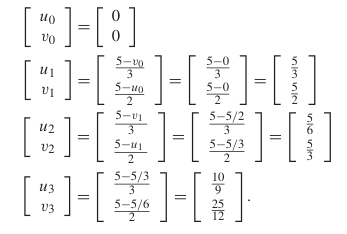

<center>

In [ ]:
# Método de jacobi

import numpy as np

matriz = np.array([[4,4,-4],[1,3,1],[2,1,5]], dtype = float)
b = np.array([0,6,5], dtype = float)
iniciales = np.array([1,1,1], dtype = float)

def jacobi(array, vector, N, tol = 1e-8, iniciales = None,):

    if array.shape[0] != array.shape[1]:
        raise ValueError('La matriz no es cuadrada')
    
    if vector.shape[0] != array.shape[0]:
        raise ValueError('Sistema incompatible')
    
    if iniciales is not None and iniciales.shape[0] != array.shape[0]:
        raise ValueError('Sistema incompatible')
    
    
    
    n = array.shape[0]
    c0 = np.zeros(n) if iniciales is None else iniciales.copy() 
    print(c0)
    c = np.zeros((n,1))
    D = np.diag(array)

    print(f"{'n':<{10}}{'x_a':<{15}}")
   
    for i in range(N):

        c = (vector - array@c0 + D*c0)/D
        

        error = np.linalg.norm(c - c0, ord=np.inf)

        print(f"{i+1:<{10}}{c}")
      
        if error < tol:
            return c
        

        c0 = c.copy()        
        
    return c 

c = jacobi(matriz, b, 50, 1e-8, iniciales)
print(f"La solución al sistema es {c}")



[1. 1. 1.]
n         x_a            
1         [0.         1.33333333 0.4       ]
2         [-0.93333333  1.86666667  0.73333333]
3         [-1.13333333  2.06666667  1.        ]
4         [-1.06666667  2.04444444  1.04      ]
5         [-1.00444444  2.00888889  1.01777778]
6         [-0.99111111  1.99555556  1.        ]
7         [-0.99555556  1.99703704  0.99733333]
8         [-0.9997037   1.99940741  0.99881481]
9         [-1.00059259  2.0002963   1.        ]
10        [-1.0002963   2.00019753  1.00017778]
11        [-1.00001975  2.00003951  1.00007901]
12        [-0.99996049  1.99998025  1.        ]
13        [-0.99998025  1.99998683  0.99998815]
14        [-0.99999868  1.99999737  0.99999473]
15        [-1.00000263  2.00000132  1.        ]
16        [-1.00000132  2.00000088  1.00000079]
17        [-1.00000009  2.00000018  1.00000035]
18        [-0.99999982  1.99999991  1.        ]
19        [-0.99999991  1.99999994  0.99999995]
20        [-0.99999999  1.99999999  0.99999998]
21    

A tener en cuenta que el método de Jacobi solo asegura convergencia si la matriz es diagonal estrictamente dominante. Es decir el valor absoluto de los elementos $a_{ii}$ de la diagonal es mayor que la suma de los valores absolutos de los demás elementos de la fila.

# Método de Gauss-Seidel

Relacionado con el métodod e Jacobi existe una iteración llamada método de Gauss-Seidel. En esta a diferencia de Jacobi, se usan los elementos más recientemente actualizados en cada paso (eso inclute el paso actual).

<center>

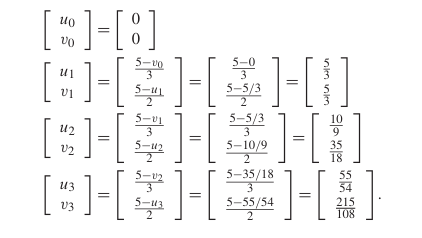

<center>

In [ ]:

import numpy as np

# Método de Gauss Seidel

def gauss_seidel(array, vector, N, tol = 1e-8, iniciales = None):

    if array.shape[0] != array.shape[1]:
        raise ValueError('La matriz no es cuadrada')
    
    if vector.shape[0] != array.shape[0]:
        raise ValueError('Sistema incompatible')
    
    if iniciales is not None and iniciales.shape[0] != array.shape[0]:
        raise ValueError('Sistema incompatible')

    n = vector.shape[0]
    x0 = np.zeros(n) if iniciales is None else iniciales.copy()
    x = np.zeros(n)
    


    for k in range(N):

        

        for i in range(n):


            x[i] = (vector[i] - array[i, :i]@x[:i] - array[i, i+1:]@x0[i+1:] )/array[i,i]
         

        error = np.linalg.norm(x - x0, ord=np.inf)

        print(k, x0, x, error)

        if error < tol:
            return x
        
        x0 = x.copy()
        
        
         
        
    return x

matriz = np.array([[3,1],[1,2]], dtype = float)
b = np.array([5,5], dtype = float)


x = gauss_seidel(matriz,b,20)
print(f"La solución al sistema es {x}")





        







0 [0. 0.] [1.66666667 1.66666667] 1.6666666666666667
1 [1.66666667 1.66666667] [1.11111111 1.94444444] 0.5555555555555556
2 [1.11111111 1.94444444] [1.01851852 1.99074074] 0.09259259259259278
3 [1.01851852 1.99074074] [1.00308642 1.99845679] 0.015432098765431945
4 [1.00308642 1.99845679] [1.0005144 1.9997428] 0.002572016460905324
5 [1.0005144 1.9997428] [1.00008573 1.99995713] 0.0004286694101509614
6 [1.00008573 1.99995713] [1.00001429 1.99999286] 7.14449016918639e-05
7 [1.00001429 1.99999286] [1.00000238 1.99999881] 1.1907483615125614e-05
8 [1.00000238 1.99999881] [1.0000004 1.9999998] 1.9845806025209356e-06
9 [1.0000004 1.9999998] [1.00000007 1.99999997] 3.3076343397553387e-07
10 [1.00000007 1.99999997] [1.00000001 1.99999999] 5.512723877387771e-08
11 [1.00000001 1.99999999] [1. 2.] 9.187873128979618e-09
La solución al sistema es [1. 2.]
